In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import seaborn as sns
from helper import *
from plots import *
import random

In [232]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [233]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Attribute Information

    age: возраст
    workclass: тип работодателя
    fnlwgt: кол-во человек такого же типа, чисто техническая инфа которая не несёт в себе смысла, можно удалить
    education: уровень образования
    education-num: число лет обучения
    marital-status: семейное положение
    occupation: род занятий
    relationship: семейная роль
    race: раса
    sex: пол
    capital-gain: прирост капитала
    capital-loss: потеря капитала
    hours-per-week: рабочих часов в неделю
    native-country: страна происхождения
    class: уровень дохода (>50K / <=50K) --- TARGET

# 1. Просмотр данных

In [234]:
data = pd.read_csv('adult.csv')
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [235]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [236]:
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [237]:
data.describe(include='str')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


# 2. Проверка корректности данных

In [238]:
data.duplicated().sum()

np.int64(52)

In [239]:
data.drop_duplicates(inplace=True)

In [240]:
# в колонке workclass обнаружен знак вопроса. возможно есть другие виды пропусков и в других колонках.
# в числовых пропусков нет, тк это было бы видно по data.info() либо же они имели тип данных str


suspicious = ['?', '??', 'unknown', 'Unknown', 'NA', 'N/A', 'na', 'null', 'None', '-', '--', ' ', '']
cat_cols = data.select_dtypes(include='str').columns

for col in cat_cols:
    vals = data[col].astype(str).unique()
    found = [v for v in vals if v.strip() in suspicious]
    if found:
        print(col, found)

workclass ['?']
occupation ['?']
native-country ['?']


In [241]:
data = data.replace('?', np.nan)

In [242]:
data.isna().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [243]:
# проверка корректности числовых значений

print(len(data[data['age'] < 0]))
print(len(data[data['age'] > 100]))
print(len(data[data['capital-gain'] < 0]))
print(len(data[data['capital-loss'] < 0]))
print(len(data[data['hours-per-week'] < 0]))

0
0
0
0
0


In [244]:
data['gender'].value_counts()

gender
Male      32614
Female    16176
Name: count, dtype: int64

In [245]:
data['income'].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [246]:
print(data['race'].value_counts())
print("______________________________")
print(data['native-country'].value_counts())

race
White                 41714
Black                  4683
Asian-Pac-Islander     1517
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64
______________________________
native-country
United-States                 43792
Mexico                          943
Philippines                     294
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Poland                           87
Guatemala                        86
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                   

In [247]:
print(data['occupation'].value_counts())

occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64


# 3. Построение графиков признаков
Для более детального изучения

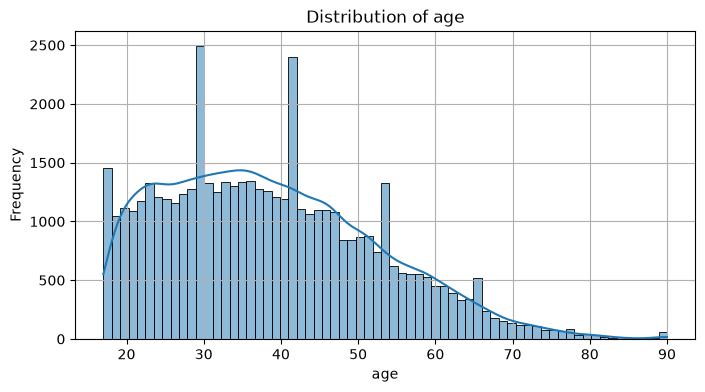

In [248]:
plot_hist_numeric(data, 'age')

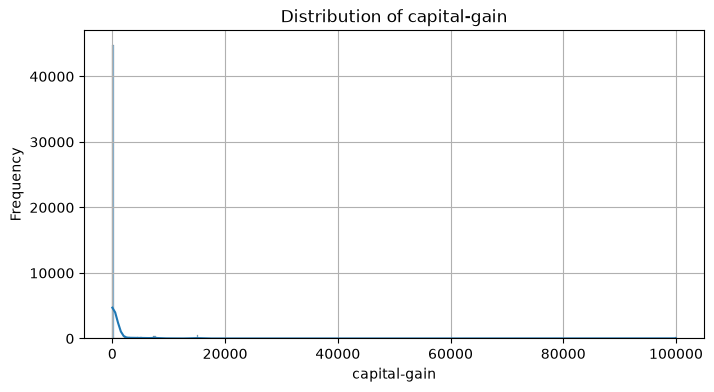

In [249]:
plot_hist_numeric(data, 'capital-gain')

По гистограме видно, что большинство имеет прирост капитала примерно = 0

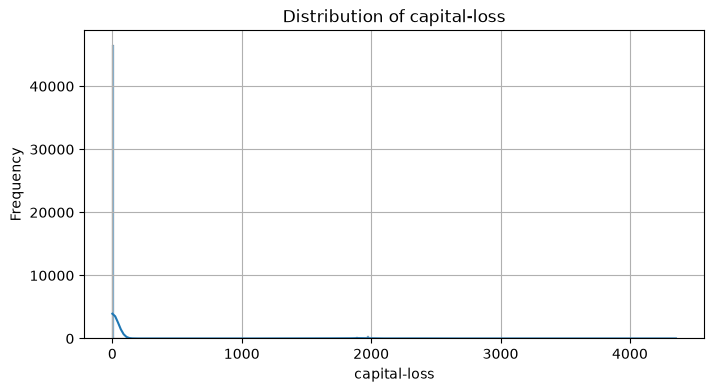

In [250]:
plot_hist_numeric(data, 'capital-loss')

Аналогичная ситуация. Большинство объектов таблицы имеют капитальные убытки примерно = 0

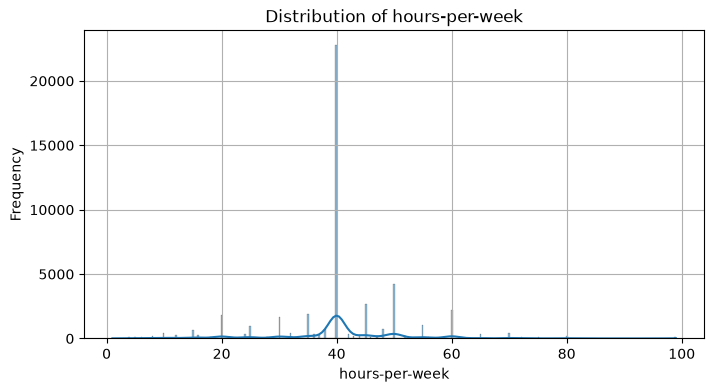

In [251]:
plot_hist_numeric(data, 'hours-per-week')

Здесь видно, что большинство людей работает от 20 до 60 часов в неделю, остальные либо меньше, либо больше

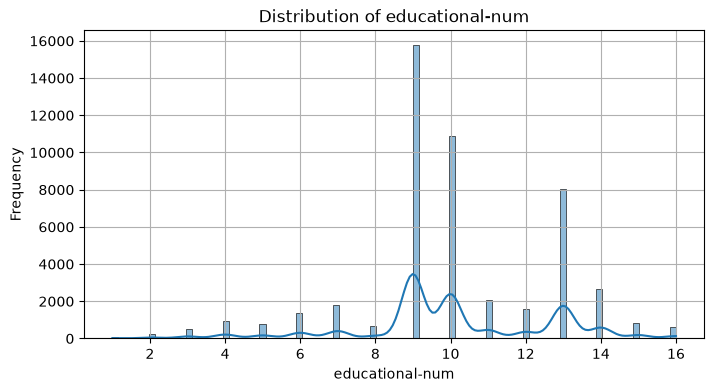

In [252]:
plot_hist_numeric(data, 'educational-num')

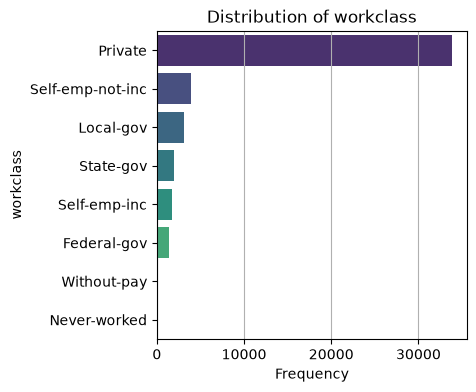

In [253]:
plot_hist_categorical(data, 'workclass')

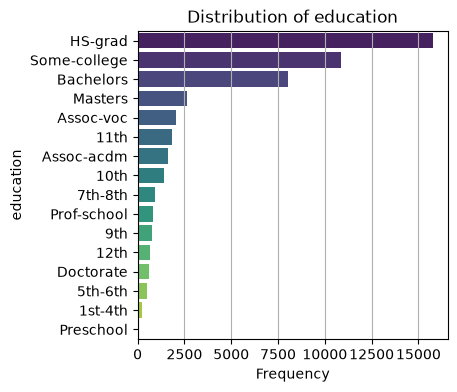

In [254]:
plot_hist_categorical(data, 'education')

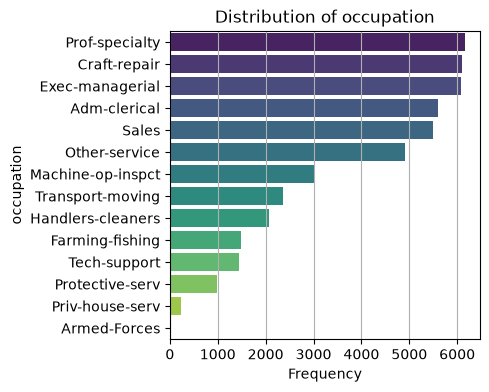

In [255]:
plot_hist_categorical(data,'occupation')

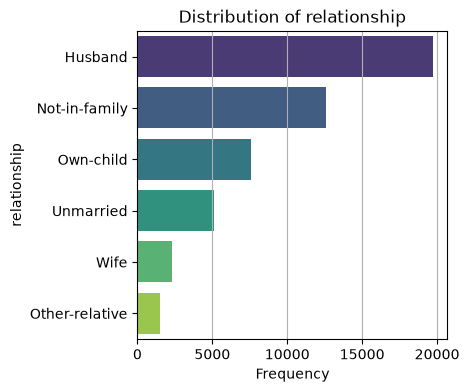

In [256]:
plot_hist_categorical(data,'relationship')

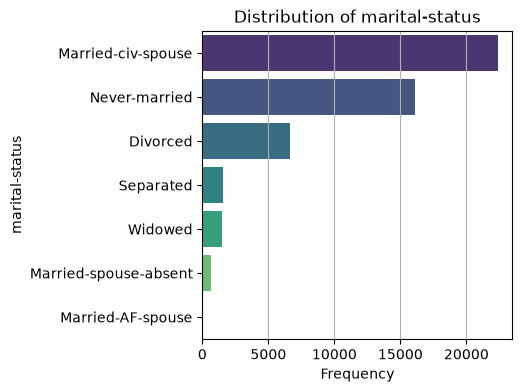

In [257]:
plot_hist_categorical(data,'marital-status')

## Посмотрим на корреляцию

interval columns not set, guessing: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


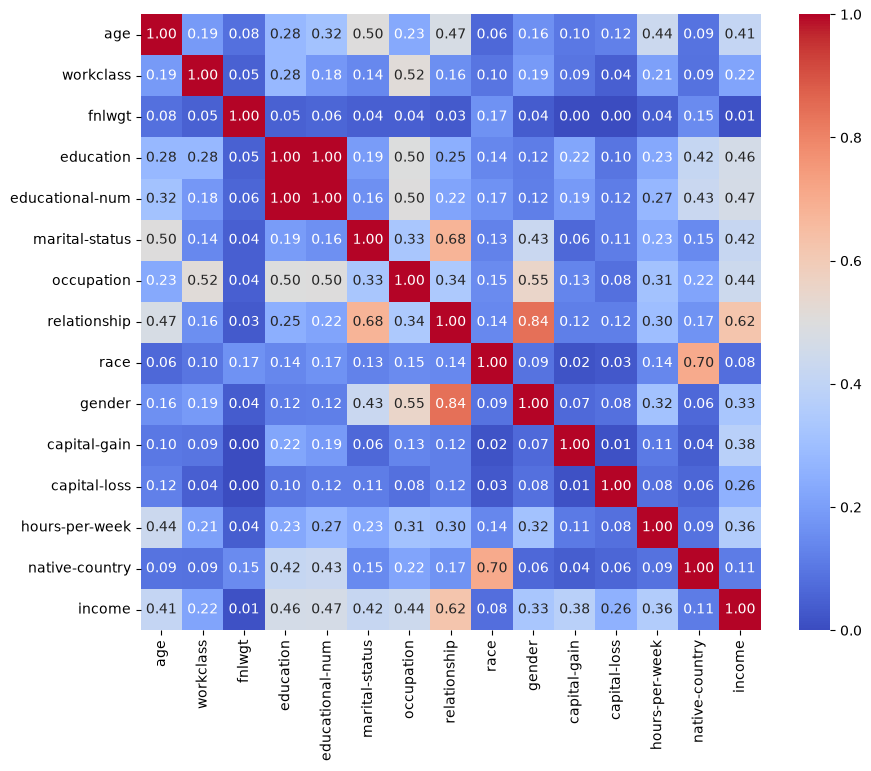

In [258]:
plot_phik(data)

По матрице корреляции видно, что колонка education практически дублирует информацию educational-num, значит education-num можно будет удалить. Встречается много признаков, которые коррелируют друг с другом (например раса и страна происхождения, отношения и гендер, отношения и статус семейного положения).


# 4. Два и более признака вместе

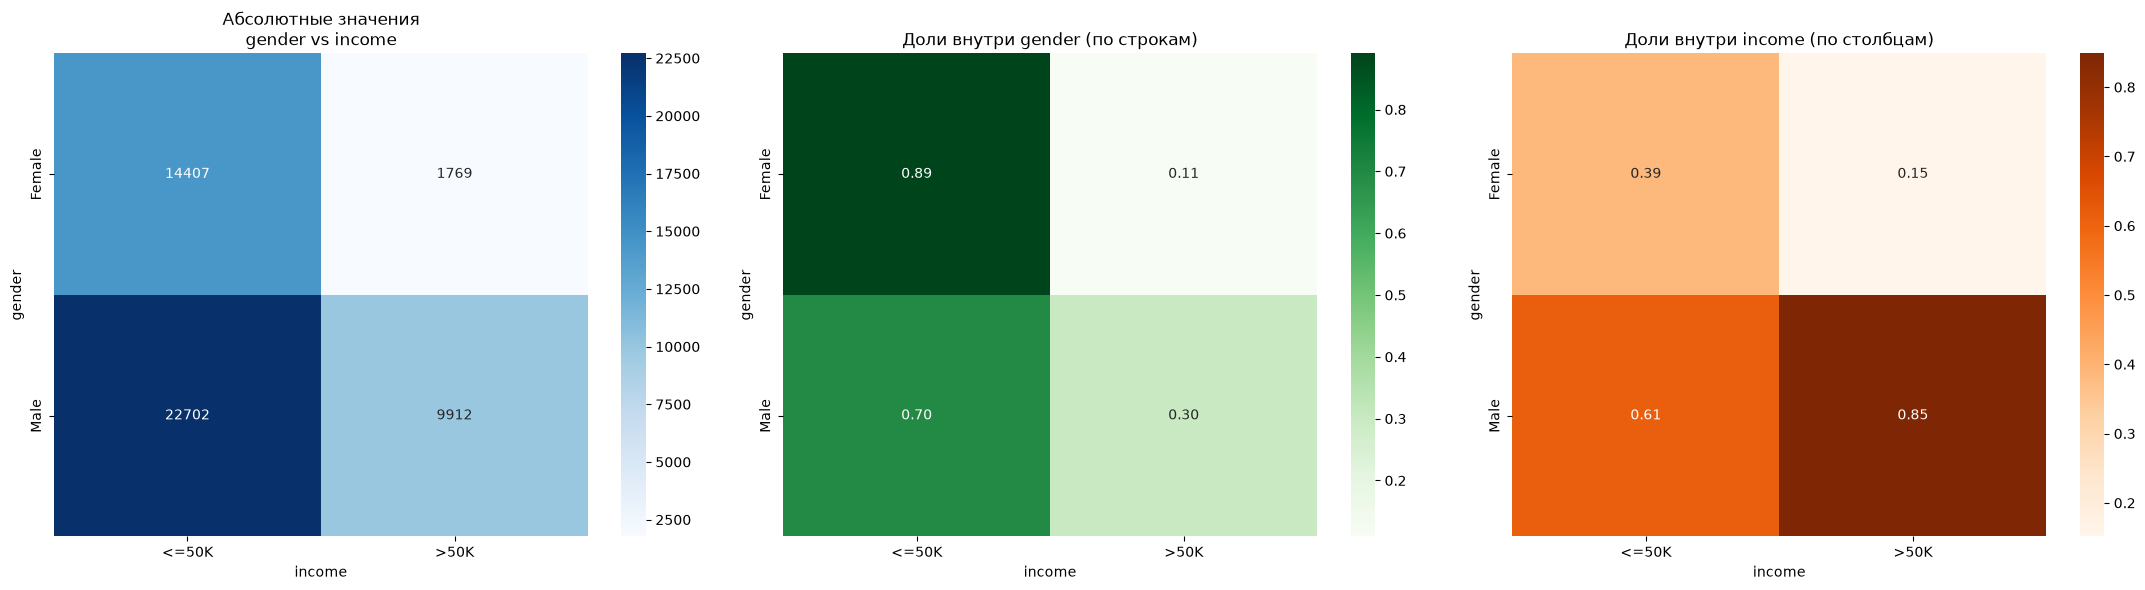

In [259]:
plot_categorical_relationship(data, 'gender', 'income')

В рассматриваемом датасете больше мужчин, чем женщин. Тем не менее, если рассматривать эти две группы по отдельности, то среди женщин бОльший процент зарабатывает <=50k. У мужчин также, но соотношение 70/30.

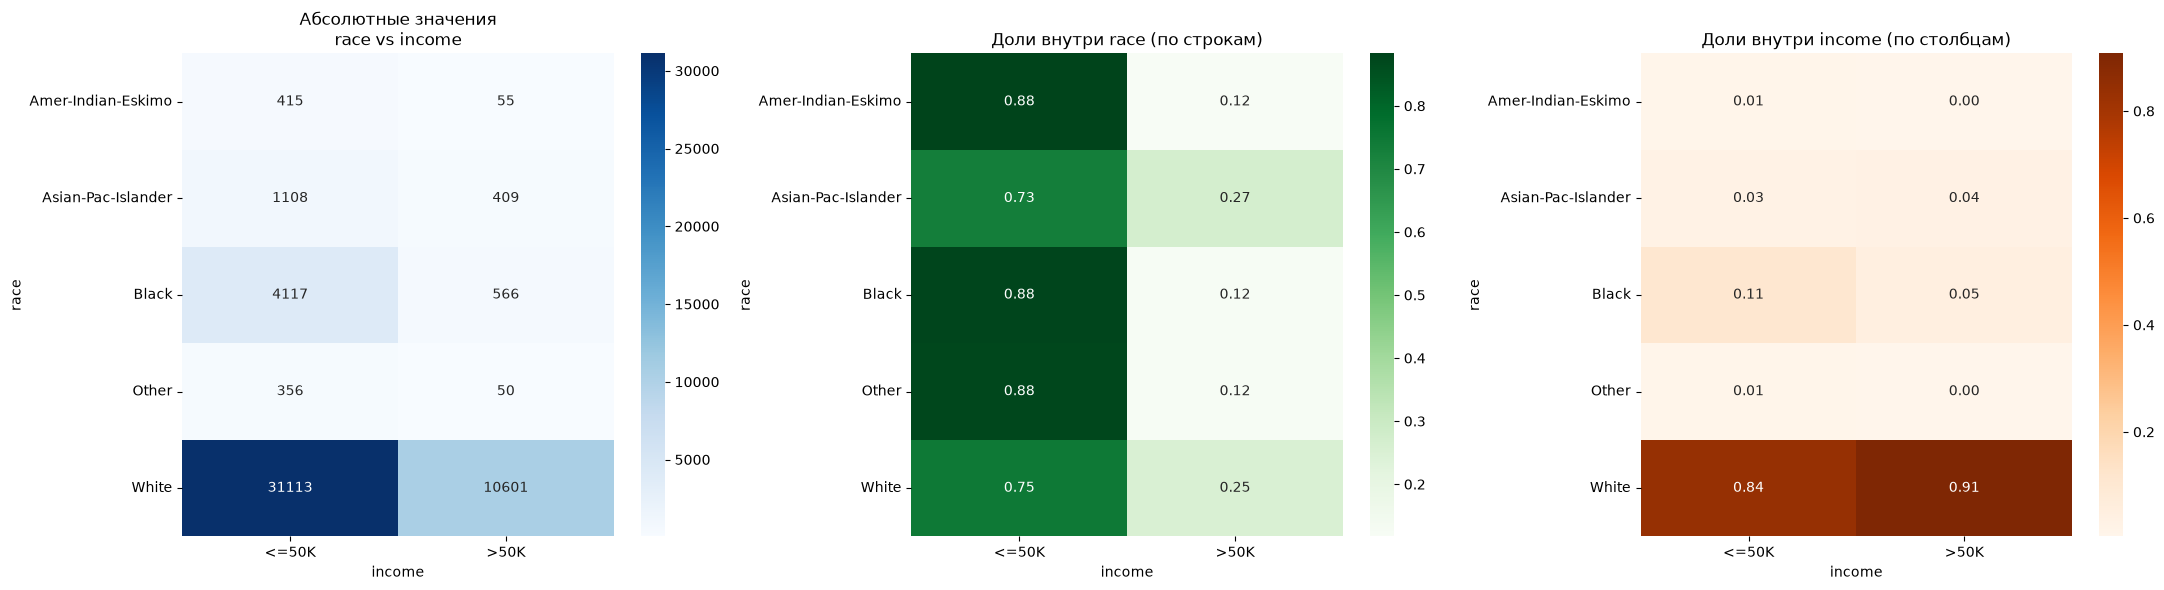

In [260]:
plot_categorical_relationship(data, 'race', 'income')

В датасете много белых людей, однако встречаются чернокожие и другие расы. Очень выделяется тот факт, что если человек не азиат и не белокожий, то в 88% случаев он будет зарабатывать <=50k. У азиавтов распределение доходов похоже на распределение доходов белокожих.

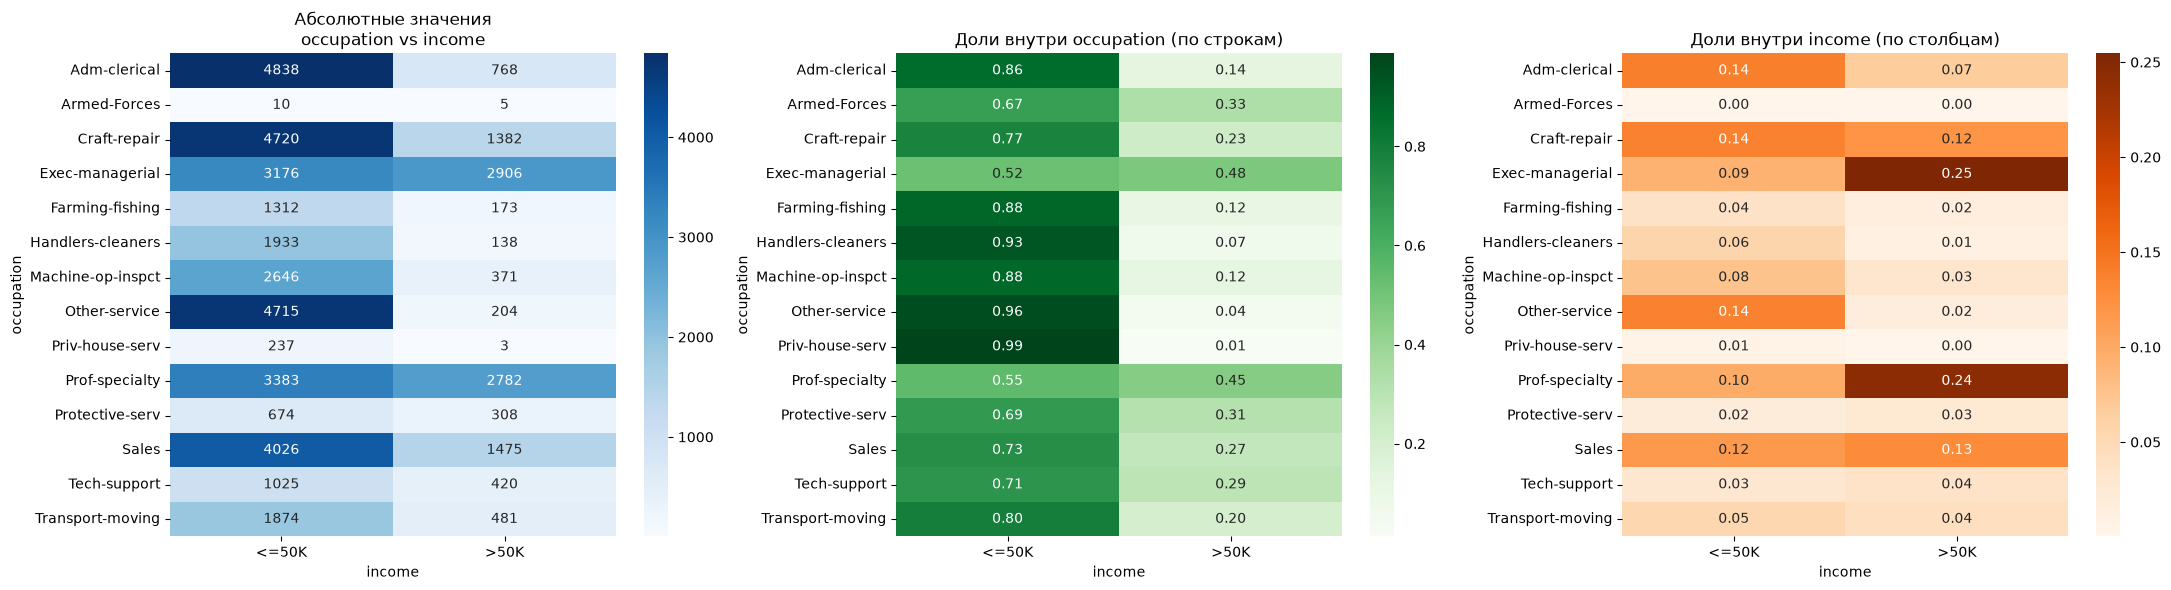

In [261]:
plot_categorical_relationship(data, 'occupation', 'income')

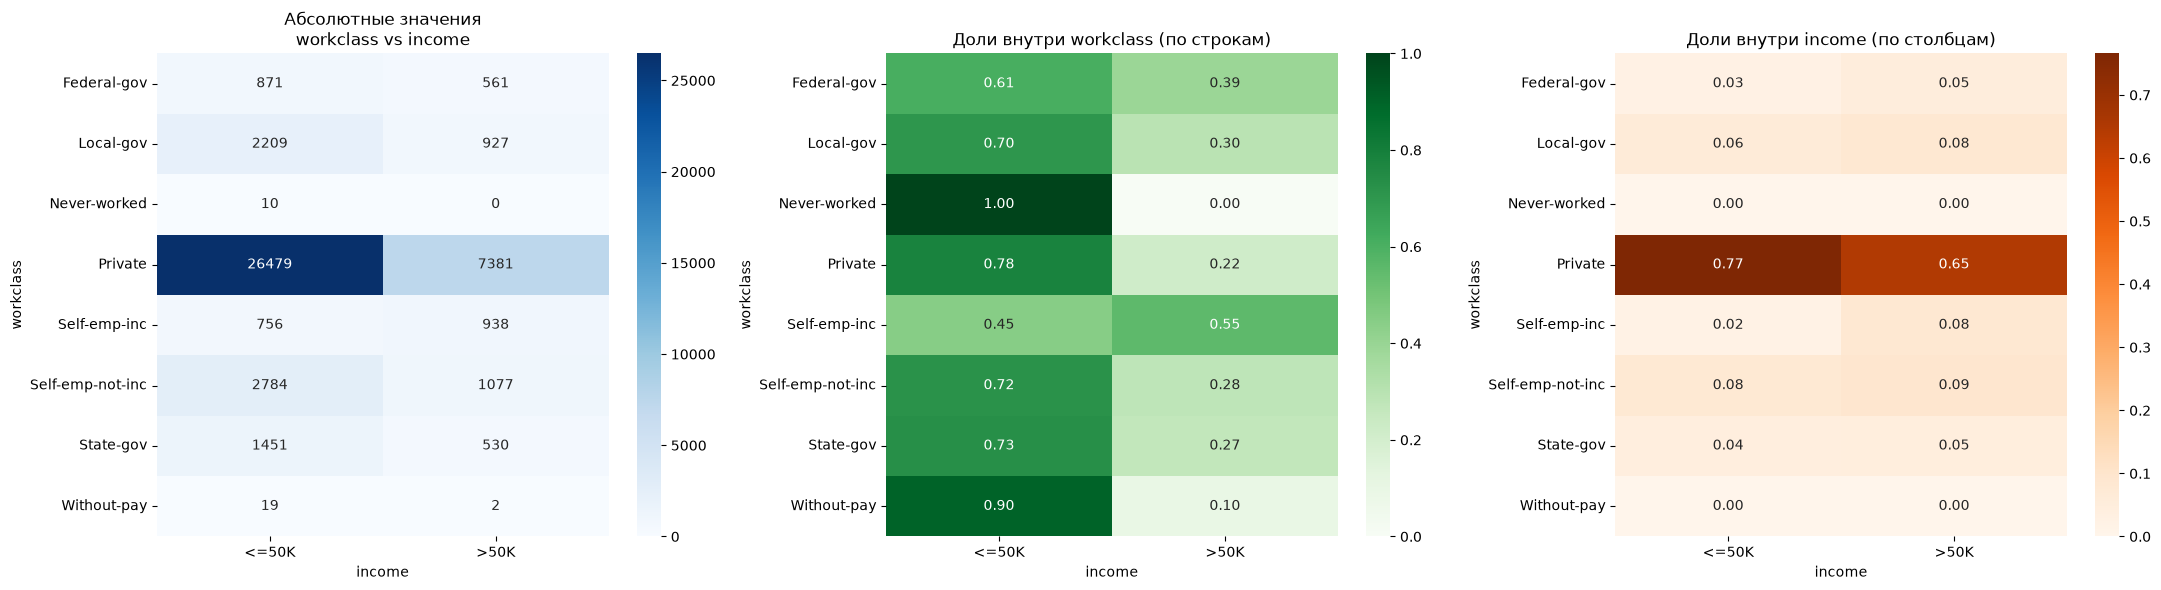

In [262]:
plot_categorical_relationship(data, 'workclass', 'income')
# never-worked, without-pay автоматически <=50k.

В данных много людей работает в найме, встречаются также ни разу не работающие (100% доход <=50k), предприниматели (self-emp-inc) c перевесом в доход >50k, люди без оплаты (without-pay 90% <=50k).

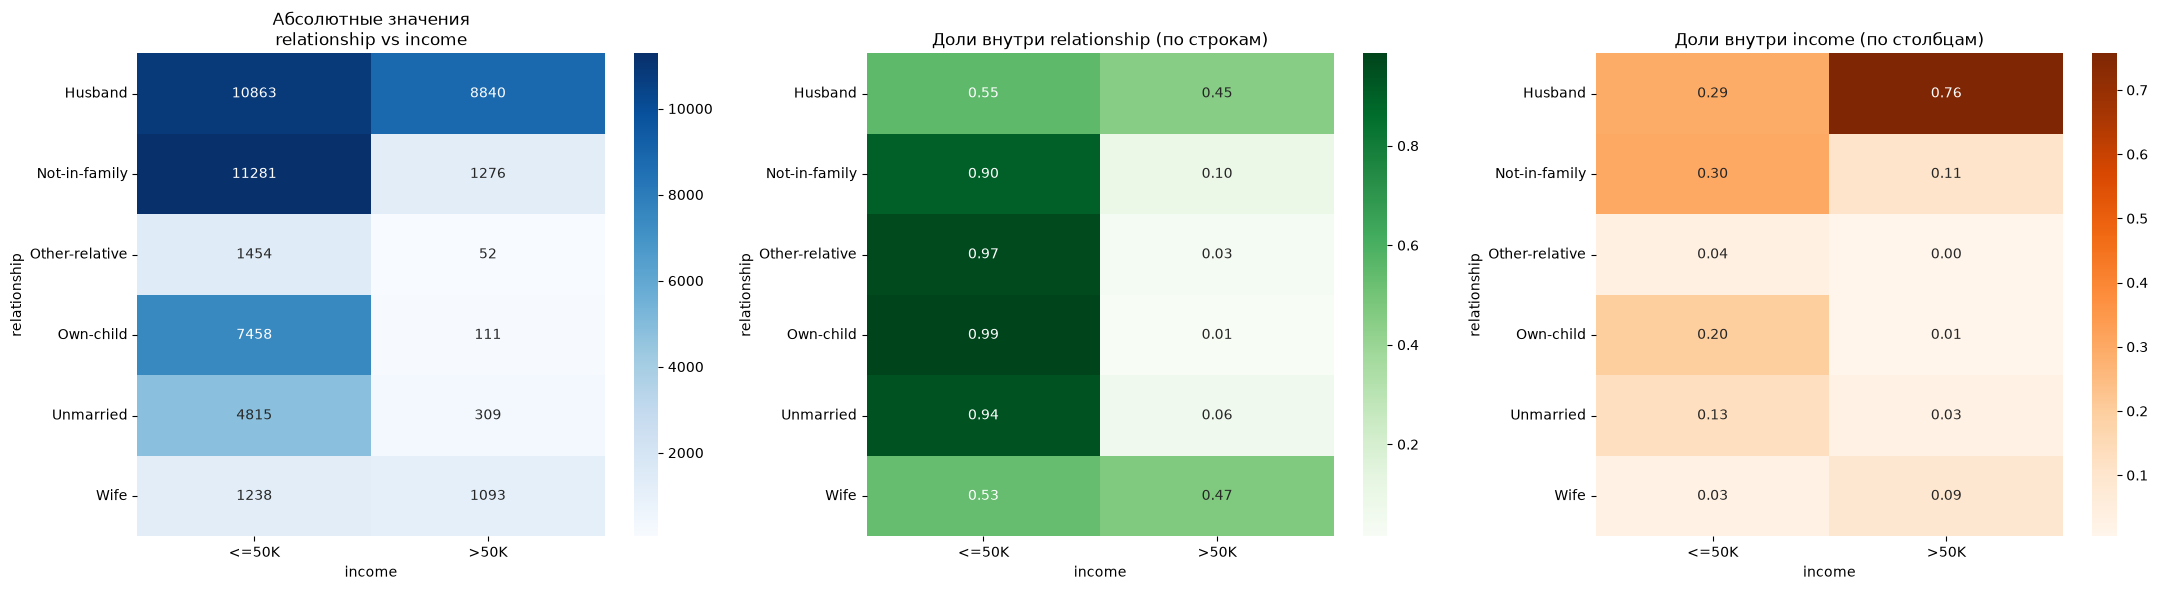

In [263]:
plot_categorical_relationship(data, 'relationship', 'income')

Если человек женат или замужем,то распределение по доходам почти одинаковое. В остальных категориях существенный перевес в сторону <=50k. 

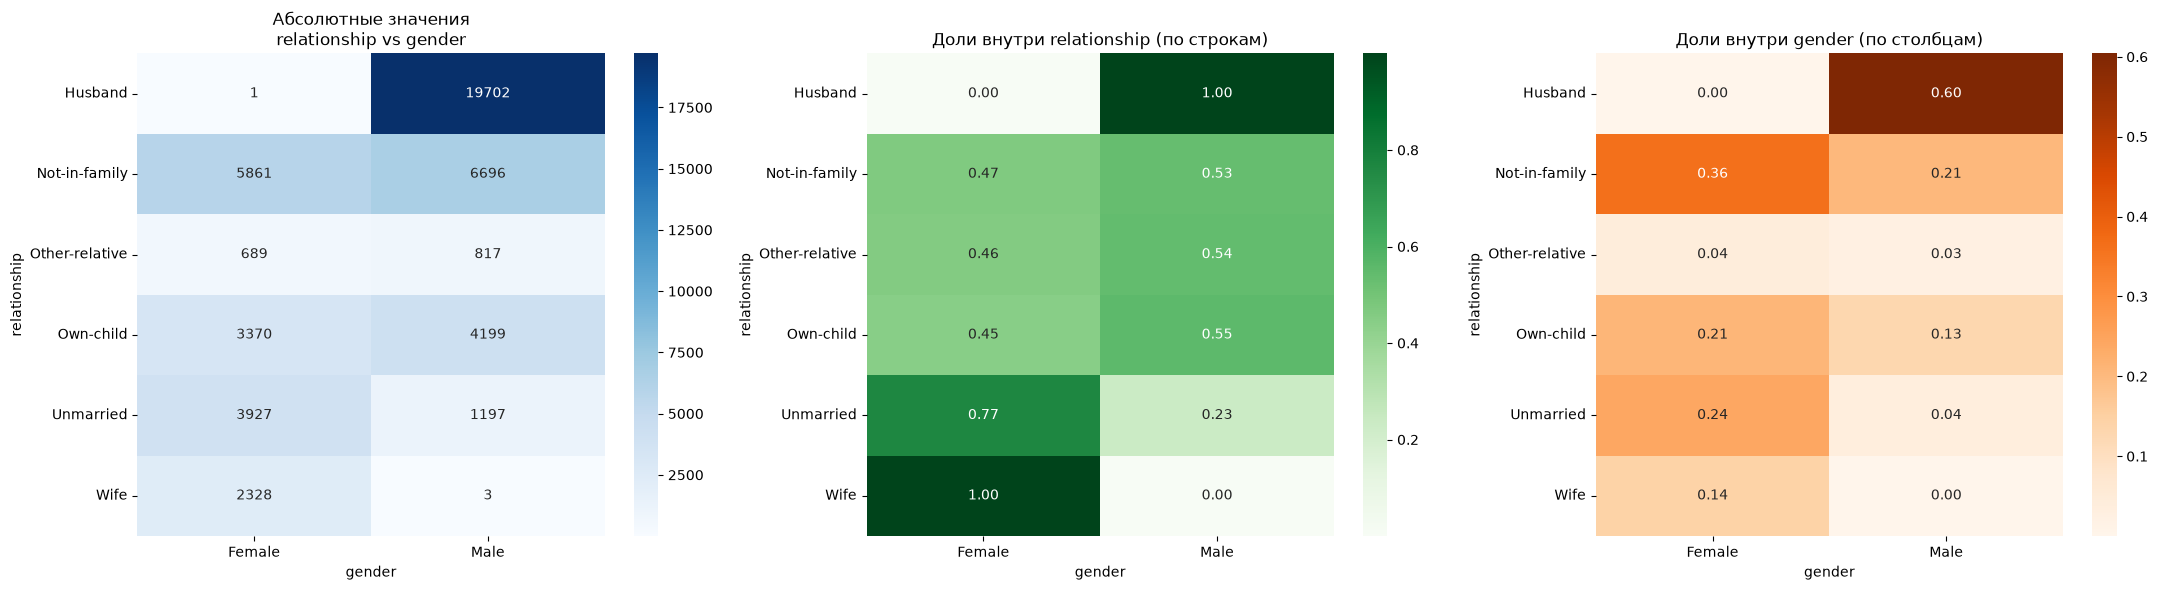

In [264]:
plot_categorical_relationship(data, 'relationship', 'gender')

Тут видна ошибка в данных. Мужчина не может быть женой в отношениях, а женщина не может быть мужем в отношениях. Возможно это просто опечатка в роли, смысл остаётся не тронутым - человек в браке.

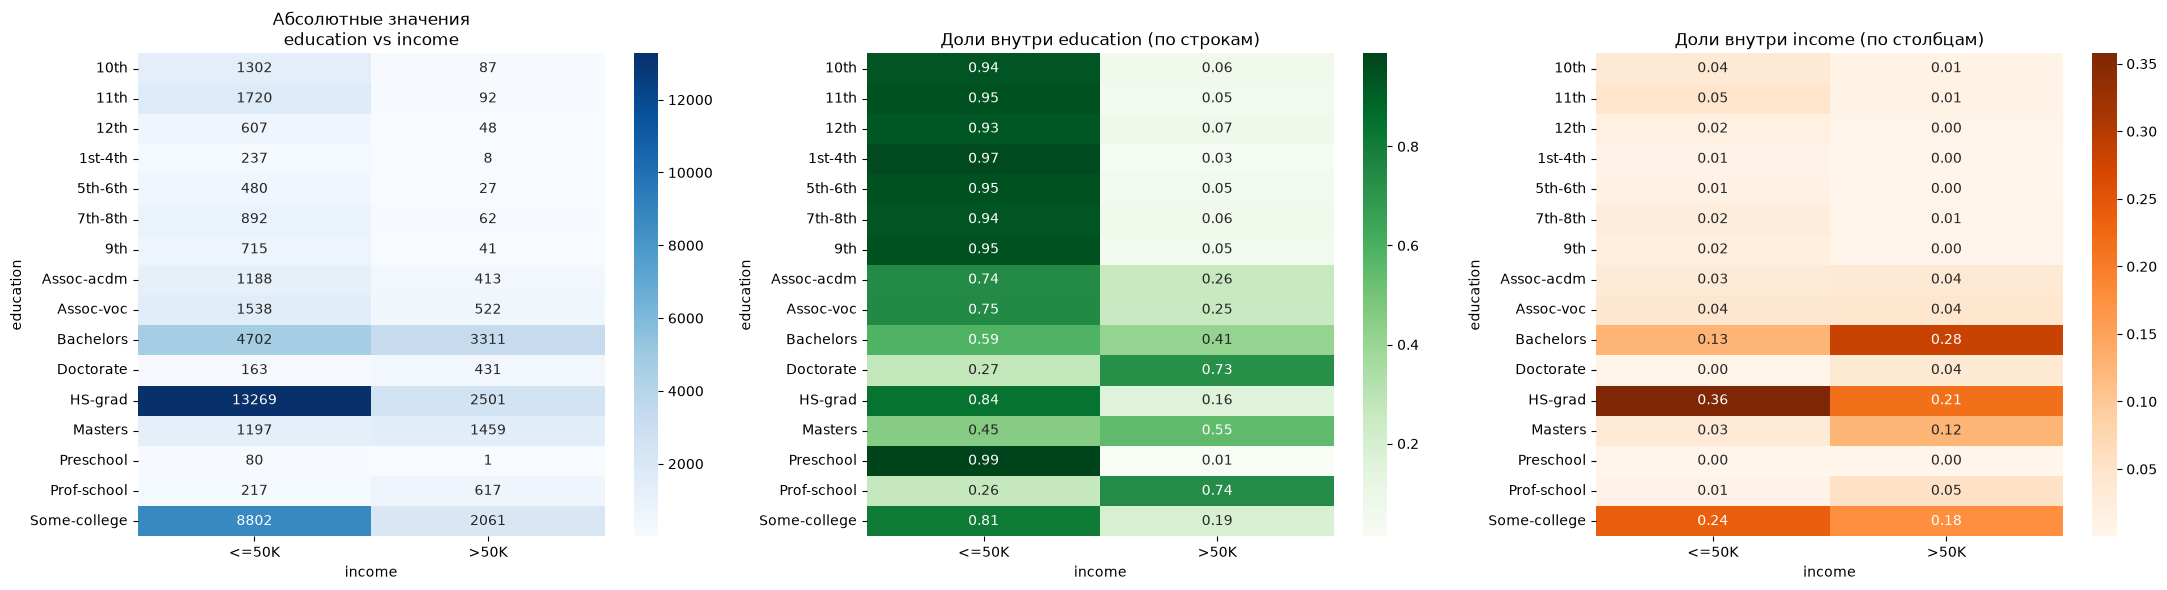

In [265]:
plot_categorical_relationship(data, 'education', 'income')

Люди без высшего образования чаще всего зарабатывают <=50k. Люди, окончившие бакалавриат зарабатывают в 41% >50k. Если человек окончил магистратуру, специализированные курсы (prof-school) или докторнатуру, то он чаще всего зарабатывает >50k.

# 5. Снижение кол-ва категорий, удаление лишних колонок

In [306]:
df_processed = data.copy()

In [307]:
df_processed.drop(['educational-num'], axis=1, inplace=True)  # Удалим educational-num, поскольку информация оттуда дублируется в education.

После того как заполнили пропуски, приступим к уменьшению количества категорий. Начнём с education. Судя по графику education*income, лучше всего сделать 6 похожих групп. Далее воспользуемся порядковым кодированием, но это ближе к Pipeline

In [308]:
df_processed['education'].value_counts()

education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

In [309]:
education_map = {
    'Preschool': 'School',
    '1st-4th':   'School',
    '5th-6th':   'School',
    '7th-8th':   'School',
    '9th':       'School',
    '10th':      'School',
    '11th':      'School',
    '12th':      'School',

    'HS-grad':      'HS-grad',
    'Some-college': 'Some-college',

    'Assoc-voc':  'Assoc',
    'Assoc-acdm': 'Assoc',

    'Bachelors':   'Bachelors',

    'Masters':     'Post-grad',
    'Prof-school': 'Post-grad',
    'Doctorate':   'Post-grad',
}

df_processed['education_group'] = df_processed['education'].map(education_map)
df_processed['education_group'].value_counts()

education_group
HS-grad         15770
Some-college    10863
Bachelors        8013
School           6399
Post-grad        4084
Assoc            3661
Name: count, dtype: int64

In [310]:
df_processed.drop(columns=['education', 'fnlwgt'], inplace=True)

Теперь уменьшим количество категорий в nation-country. Предлагаю воспользоваться знаниями из экономической географии и объединить страны подобным образом в 6-7 категорий.

In [311]:
country_map = {
    'United-States': 'US',
    'Canada': 'Anglo',
    'England': 'Anglo',
    'Australia': 'Anglo',
    'Ireland': 'Anglo',
    'Scotland': 'Anglo',

    'Mexico': 'LatAm',
    'Puerto-Rico': 'LatAm',
    'Cuba': 'LatAm',
    'Jamaica': 'LatAm',
    'Dominican-Republic': 'LatAm',
    'El-Salvador': 'LatAm',
    'Guatemala': 'LatAm',
    'Columbia': 'LatAm',
    'Haiti': 'LatAm',
    'Honduras': 'LatAm',
    'Nicaragua': 'LatAm',
    'Peru': 'LatAm',
    'Trinadad&Tobago': 'LatAm',
    'Ecuador': 'LatAm',

    'Germany': 'Europe',
    'Italy': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'France': 'Europe',
    'Greece': 'Europe',
    'Holand-Netherlands': 'Europe',
    'Hungary': 'Europe',
    'Yugoslavia': 'Europe',

    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    'Taiwan': 'Asia',
    'Iran': 'Asia',
    'Thailand': 'Asia',
    'Hong': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',
}

df_processed['country_group'] = df_processed['native-country'].map(country_map)

In [312]:
print(df_processed.shape)
print(df_processed['country_group'].value_counts().sum())
df_processed['country_group'].value_counts()

(48790, 14)
47796


country_group
US        43792
LatAm      2062
Asia        980
Europe      595
Anglo       367
Name: count, dtype: int64

In [313]:
df_processed.drop(columns=['native-country'], inplace=True)

Семейное положение и роль в домохозяйстве тоже требует уменьшения количества категорий. В marital-status предлагаю 4 категории: в браке, никогда не был, не в браке и непонятная ситуаия. В relationship предлагаю оставить только роль own-child, поскольку другие категории не вносят сильно новой информации в данные.

In [314]:
pd.crosstab(data['relationship'], data['marital-status'])

marital-status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,0,12,19691,0,0,0,0
Not-in-family,3626,0,23,329,7091,637,851
Other-relative,181,1,201,54,920,79,70
Own-child,455,1,143,61,6738,146,25
Unmarried,2368,0,0,183,1333,668,572
Wife,0,23,2308,0,0,0,0


In [315]:
df_processed['Own-child'] = (df_processed['relationship'] == 'Own-child').astype(int)

In [316]:
df_processed['marital-status'].value_counts()

marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

In [317]:
marital_map = {
    'Married-civ-spouse':    'Married',
    'Married-AF-spouse':     'Married',

    'Married-spouse-absent': 'Married-absent',

    'Divorced':  'Was married',
    'Separated': 'Was married',
    'Widowed':   'Was married',

    'Never-married': 'Never married',
}

df_processed['marital_group'] = df_processed['marital-status'].map(marital_map)

# Проверка
print(df_processed['marital_group'].isna().sum())
print(df_processed['marital_group'].value_counts())

0
marital_group
Married           22403
Never married     16082
Was married        9678
Married-absent      627
Name: count, dtype: int64


In [318]:
df_processed.drop(columns=['marital-status', 'relationship'], inplace=True)

In [319]:
df_processed

,age,workclass,occupation,race,gender,capital-gain,capital-loss,hours-per-week,income,education_group,country_group,Own-child,marital_group
0,25,Private,Machine-op-inspct,Black,Male,0,0,40,<=50K,School,US,1,Never married
1,38,Private,Farming-fishing,White,Male,0,0,50,<=50K,HS-grad,US,0,Married
2,28,Local-gov,Protective-serv,White,Male,0,0,40,>50K,Assoc,US,0,Married
3,44,Private,Machine-op-inspct,Black,Male,7688,0,40,>50K,Some-college,US,0,Married
4,18,NaN,NaN,White,Female,0,0,30,<=50K,Some-college,US,1,Never married
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Tech-support,White,Female,0,0,38,<=50K,Assoc,US,0,Married
48838,40,Private,Machine-op-inspct,White,Male,0,0,40,>50K,HS-grad,US,0,Married
48839,58,Private,Adm-clerical,White,Female,0,0,40,<=50K,HS-grad,US,0,Was married
48840,22,Private,Adm-clerical,White,Male,0,0,20,<=50K,HS-grad,US,1,Never married


Оставим только 3 расы, остальные запишем в other.

In [320]:
race_map = {
    'White':               'White',
    'Black':               'Black',
    'Asian-Pac-Islander':  'Asian',
    'Amer-Indian-Eskimo':  'Other',
    'Other':               'Other',
}

df_processed['race_group'] = df_processed['race'].map(race_map)

In [321]:
df_processed.drop(columns=['race'], inplace=True)

In [322]:
df_processed['workclass'].value_counts()

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Категория работы тоже требует уменьшения. Оставим людей из найма, предпринимателей, госслужащих. Остальные получат категорию other. 

In [323]:
workclass_map = {
    'Private':          'Private',
    'Self-emp-inc':     'Entrepreneur',
    'Self-emp-not-inc': 'Self-emp',       
    'Federal-gov':      'Gov',
    'Local-gov':        'Gov',
    'State-gov':        'Gov',
    'Without-pay':      'No-income',
    'Never-worked':     'No-income',
}

df_processed['workclass_group'] = df_processed['workclass'].map(workclass_map)

In [324]:
df_processed['workclass_group'].value_counts()

workclass_group
Private         33860
Gov              6549
Self-emp         3861
Entrepreneur     1694
No-income          31
Name: count, dtype: int64

In [325]:
df_processed.drop(columns=['workclass'], inplace=True)

Также стоит уменьшить количество категорий в роде деятельности людей. 6 категорий: белвые воротнички с высоким доходом, белые воротнички с низким, синие воротнички, продажники, сервис услуг и другие.

In [326]:
df_processed['occupation'].value_counts()

occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

In [327]:
occupation_map = {
    'Prof-specialty':  'High white-collar',
    'Exec-managerial': 'High white-collar',

    'Adm-clerical':    'Low white-collar',
    'Tech-support':    'Low white-collar',

    'Sales':           'Sales',

    'Other-service':   'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',

    'Craft-repair':      'Blue-collar',
    'Machine-op-inspct': 'Blue-collar',
    'Transport-moving':  'Blue-collar',
    'Handlers-cleaners': 'Blue-collar',

    'Farming-fishing': 'Other',
    'Armed-Forces':    'Other',
}

df_processed['occupation_group'] = df_processed['occupation'].map(occupation_map)

In [328]:
df_processed.drop(columns=['occupation'], inplace=True)

Приведём в порядок таргетовую величину, вместо <=50k и >50k будет запись 0 и 1 соответственно.

In [329]:
df_processed['income'].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [330]:
df_processed['income'] = np.where(df_processed['income'] == '>50K', 1, 0)
df_processed['income'].value_counts()

income
0    37109
1    11681
Name: count, dtype: int64

In [331]:
df_processed

,age,gender,capital-gain,capital-loss,hours-per-week,income,education_group,country_group,Own-child,marital_group,race_group,workclass_group,occupation_group
0,25,Male,0,0,40,0,School,US,1,Never married,Black,Private,Blue-collar
1,38,Male,0,0,50,0,HS-grad,US,0,Married,White,Private,Other
2,28,Male,0,0,40,1,Assoc,US,0,Married,White,Gov,Service
3,44,Male,7688,0,40,1,Some-college,US,0,Married,Black,Private,Blue-collar
4,18,Female,0,0,30,0,Some-college,US,1,Never married,White,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Female,0,0,38,0,Assoc,US,0,Married,White,Private,Low white-collar
48838,40,Male,0,0,40,1,HS-grad,US,0,Married,White,Private,Blue-collar
48839,58,Female,0,0,40,0,HS-grad,US,0,Was married,White,Private,Low white-collar
48840,22,Male,0,0,20,0,HS-grad,US,1,Never married,White,Private,Low white-collar


interval columns not set, guessing: ['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'income', 'Own-child']


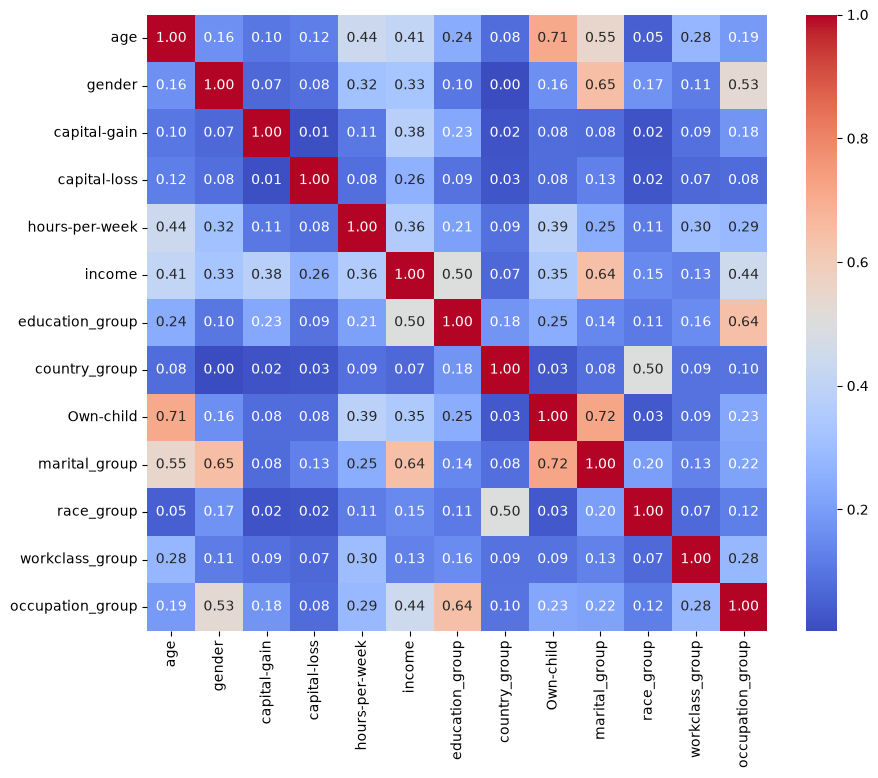

In [332]:
plot_phik(df_processed)

# 6. Train Test Split

In [333]:
X, y = df_processed.drop(columns=['income']), df_processed['income']

In [334]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED,
    stratify=y  
)

In [ ]:
X_train_preprocessed = X_train.copy()
categorical_cols_onehot = ['gender', 'country_group', 'marital_group', 'race_group', 'workclass_group', 'occupation_group']
categorical_cols_ordered = ['education_group']

In [336]:
df_processed['education_group'].value_counts()

education_group
HS-grad         15770
Some-college    10863
Bachelors        8013
School           6399
Post-grad        4084
Assoc            3661
Name: count, dtype: int64

In [337]:
category_orders = [
    ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Post-grad'], # education_group
]

encoder = OrdinalEncoder(categories=category_orders)
X_train_preprocessed[categorical_cols_ordered] = encoder.fit_transform(X_train_preprocessed[categorical_cols_ordered])

In [338]:
X_train_preprocessed['workclass_group'].value_counts()

workclass_group
Private         27088
Gov              5249
Self-emp         3104
Entrepreneur     1330
No-income          28
Name: count, dtype: int64

In [343]:
# nan-remover, one-hot, ordinal 


most_frequent_cat_cols = ['workclass_group', 'occupation_group', 'country_group']

preprocessor = Pipeline([
    ('nan_remover', ColumnTransformer(
        [
            ('most_frequent_cat', SimpleImputer(strategy='most_frequent'), most_frequent_cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )),
    ('transformations', ColumnTransformer(
        [('ordinal', OrdinalEncoder(
            categories=category_orders, 
            handle_unknown='use_encoded_value',
            unknown_value=-1,),
            categorical_cols_ordered),

         ('onehot', OneHotEncoder(
             drop='first',
             handle_unknown='ignore',
             sparse_output=False, 
         ), 
            categorical_cols_onehot)],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])
preprocessor.set_output(transform="pandas")

,steps,"[('nan_remover', ...), ('transformations', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('most_frequent_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"

In [344]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, index=X_train.index)

In [270]:
X_train_preprocessed.info()

<class 'pandas.DataFrame'>
Index: 39032 entries, 13116 to 20252
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   gender_Female                       39032 non-null  float64
 1   gender_Male                         39032 non-null  float64
 2   education_group_Bachelors           39032 non-null  float64
 3   education_group_College             39032 non-null  float64
 4   education_group_HS-grad             39032 non-null  float64
 5   education_group_Post-grad           39032 non-null  float64
 6   education_group_School              39032 non-null  float64
 7   country_group_Europe                39032 non-null  float64
 8   country_group_Latin America         39032 non-null  float64
 9   country_group_Other                 39032 non-null  float64
 10  country_group_US                    39032 non-null  float64
 11  marital_group_Married               39032 non-null  f

# 7. Baselines

In [345]:
X_test_preprocessed = preprocessor.transform(X_test)

In [346]:
feature_names = X_test_preprocessed.columns.to_list()

In [347]:
X_test_preprocessed

,education_group,gender_Male,country_group_Asia,country_group_Europe,country_group_LatAm,country_group_US,marital_group_Married-absent,marital_group_Never married,marital_group_Was married,race_group_Black,...,occupation_group_High white-collar,occupation_group_Low white-collar,occupation_group_Other,occupation_group_Sales,occupation_group_Service,age,capital-gain,capital-loss,hours-per-week,Own-child
30204,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,34,0,0,40,0
26624,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,39,0,1669,60,0
17977,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,49,0,0,43,0
20164,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,63,0,0,40,0
10557,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,34,0,0,45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32755,5.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,54,0,0,30,0
31456,4.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,28,0,0,20,0
13987,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,20,0,0,35,0
25067,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,57,0,0,38,0


/home/bibeda/DSpractice/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bibeda/DSpractice/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


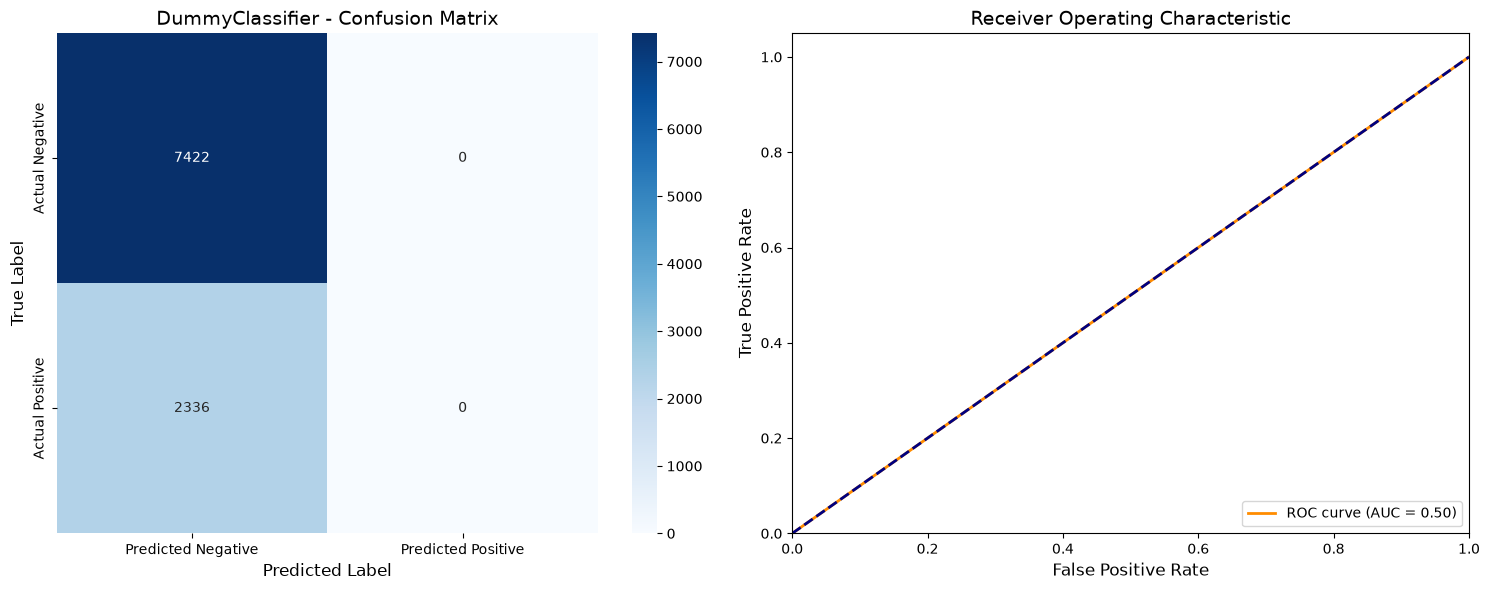


                 DUMMYCLASSIFIER EVALUATION                 

MAIN METRICS:
   Metric  Value
  ROC AUC 0.5000
 F1 Score 0.4320
Precision 0.3803
   Recall 0.5000
 Accuracy 0.7606


CLASSIFICATION REPORT:
   Class  Precision  Recall
Positive   0.000000     0.0
Negative   0.760607     1.0



In [348]:
# Задаем и обучаем модель
dummy_classifier = DummyClassifier(random_state=SEED, strategy='most_frequent')
dummy_classifier.fit(X_train_preprocessed, y_train)

# Получаем предсказания
y_pred = dummy_classifier.predict(X_test_preprocessed) # предсказываем номер класса
y_probs = dummy_classifier.predict_proba(X_test_preprocessed)[:, 1] # предсказываем вероятность (необходима для построения ROC кривой)

# Считаем метрики для модели и выводим графики
dummy_classifier_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="DummyClassifier"
)

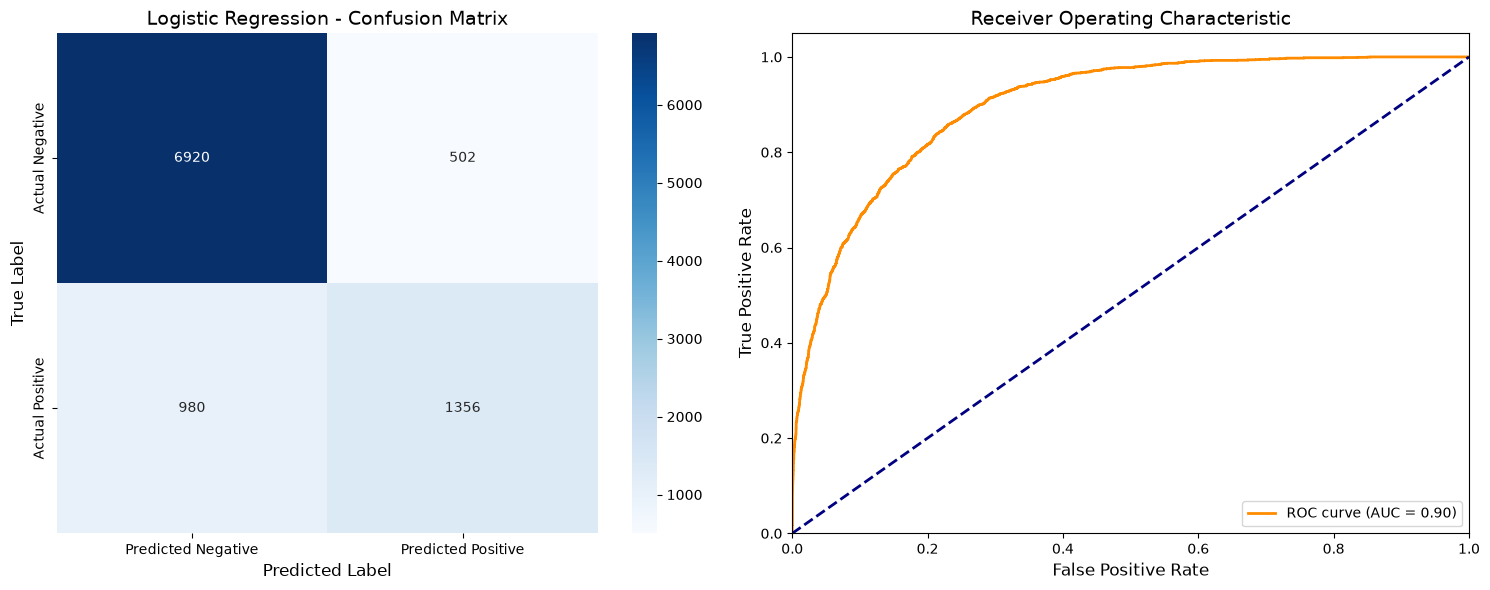


               LOGISTIC REGRESSION EVALUATION               

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8987
 F1 Score 0.7750
Precision 0.8029
   Recall 0.7564
 Accuracy 0.8481


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.729817 0.580479
Negative   0.875949 0.932363



In [349]:
log_reg = LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear')
log_reg.fit(X_train_preprocessed, y_train)

y_pred = log_reg.predict(X_test_preprocessed)
y_probs = log_reg.predict_proba(X_test_preprocessed)[:, 1]  

log_reg_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="Logistic Regression"
)

/home/bibeda/DSpractice/plots.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


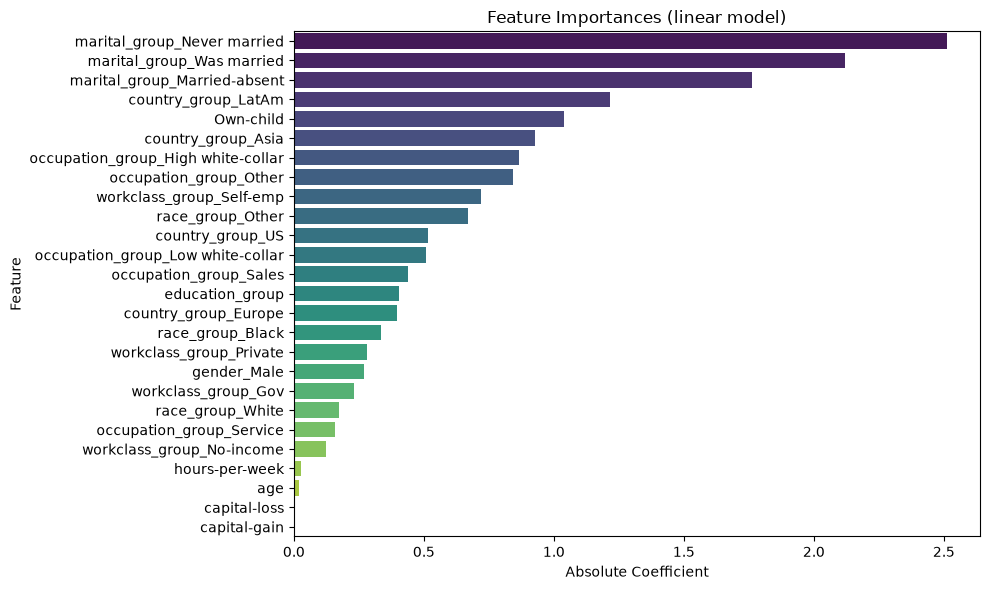

,Feature,Importance
7,marital_group_Never married,2.513455
8,marital_group_Was married,2.119685
6,marital_group_Married-absent,1.760320
4,country_group_LatAm,1.216273
25,Own-child,1.038111
2,country_group_Asia,0.927881
16,occupation_group_High white-collar,0.867203
18,occupation_group_Other,0.842254
15,workclass_group_Self-emp,0.720278
10,race_group_Other,0.668006


In [350]:

plot_feature_importance(log_reg, feature_names)

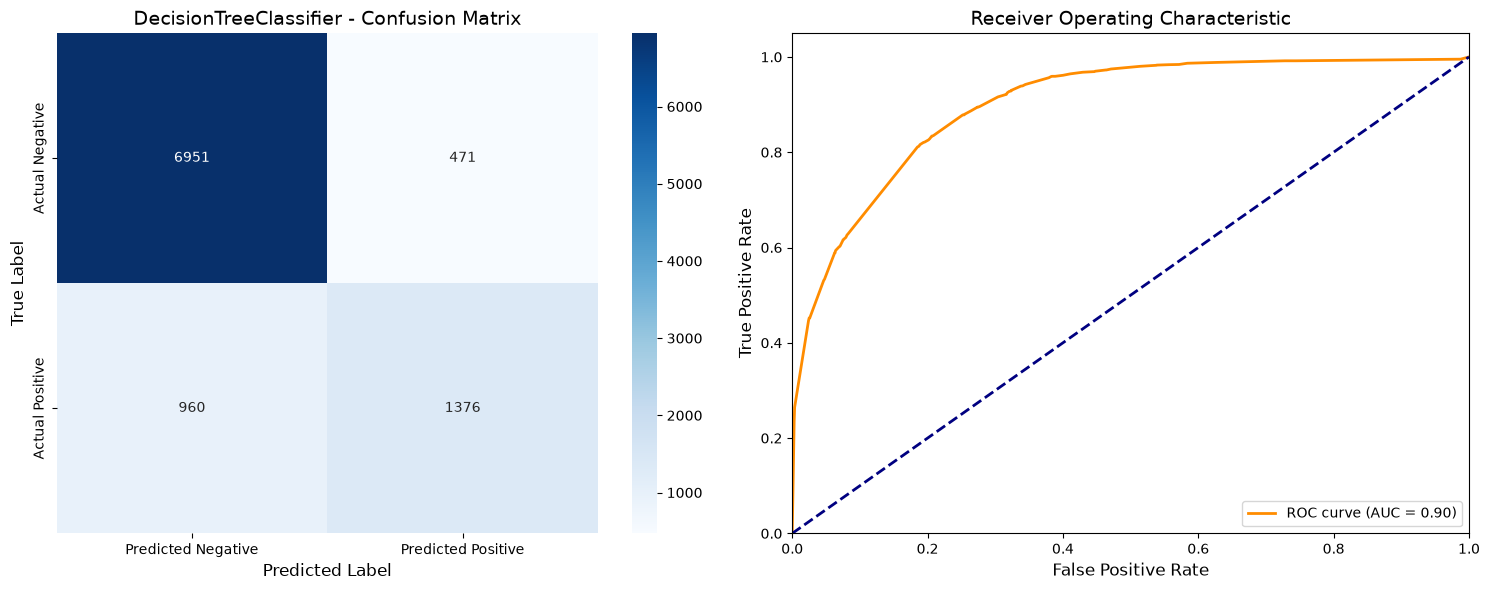


             DECISIONTREECLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8998
 F1 Score 0.7823
Precision 0.8118
   Recall 0.7628
 Accuracy 0.8534


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.744992 0.589041
Negative   0.878650 0.936540



In [355]:
decision_tree = DecisionTreeClassifier(random_state=SEED, max_depth=9)
decision_tree.fit(X_train_preprocessed, y_train)

y_pred = decision_tree.predict(X_test_preprocessed)
y_probs = decision_tree.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

decision_tree_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="DecisionTreeClassifier"
)

/home/bibeda/DSpractice/plots.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


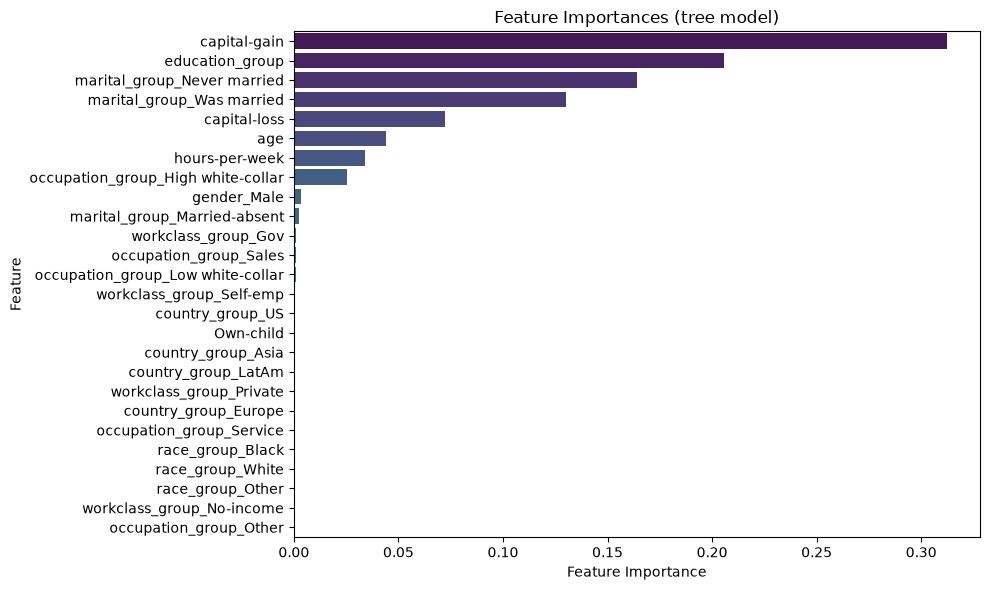

,Feature,Importance
22,capital-gain,0.312485
0,education_group,0.205864
7,marital_group_Never married,0.163956
8,marital_group_Was married,0.130292
23,capital-loss,0.072380
21,age,0.044080
24,hours-per-week,0.033853
16,occupation_group_High white-collar,0.025398
1,gender_Male,0.003499
6,marital_group_Married-absent,0.002354


In [356]:
plot_feature_importance(decision_tree, feature_names)


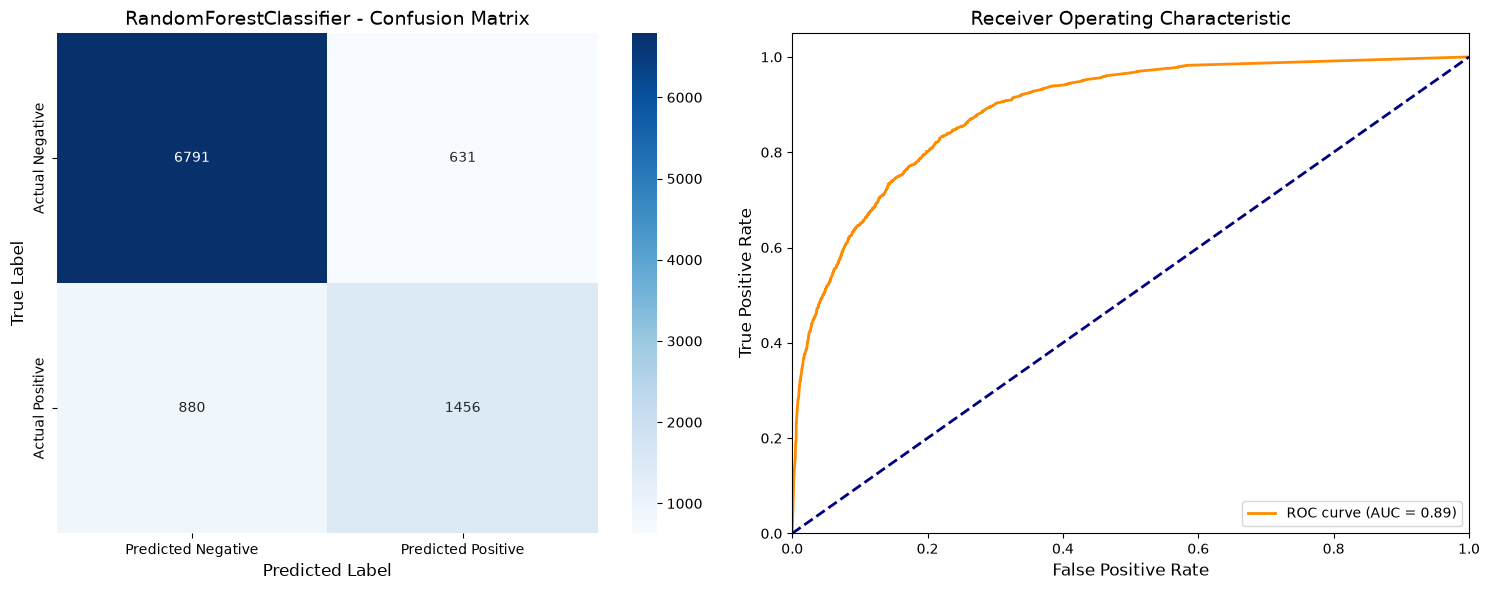


             RANDOMFORESTCLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8894
 F1 Score 0.7791
Precision 0.7915
   Recall 0.7691
 Accuracy 0.8452


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.697652 0.623288
Negative   0.885282 0.914982



In [357]:
# Train your model
random_forest = RandomForestClassifier(random_state=SEED)
random_forest.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = random_forest.predict(X_test_preprocessed)
y_probs = random_forest.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

# Evaluate
random_forest_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="RandomForestClassifier"
)

/home/bibeda/DSpractice/plots.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


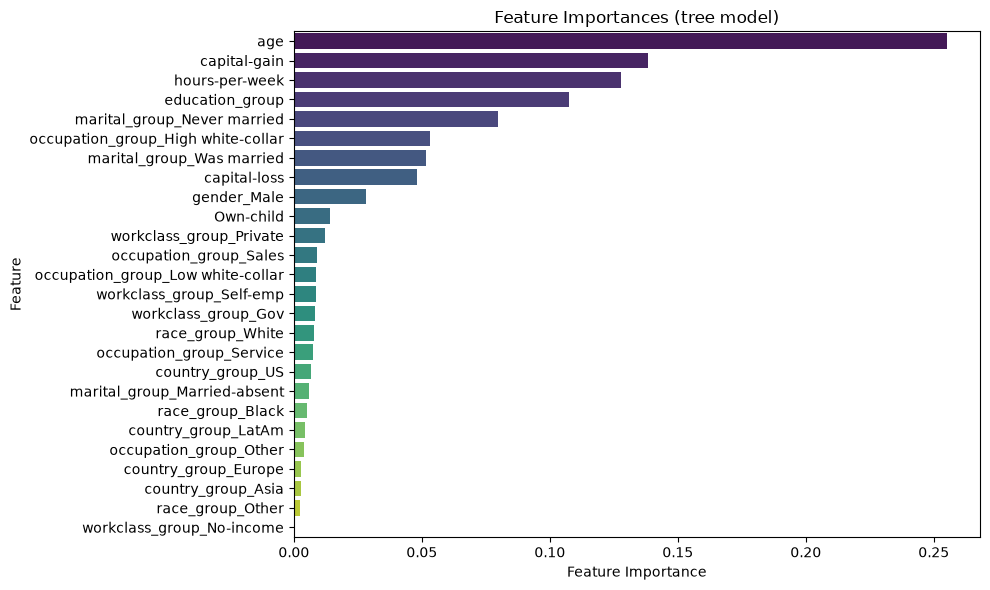

,Feature,Importance
21,age,0.255289
22,capital-gain,0.138385
24,hours-per-week,0.127707
0,education_group,0.107537
7,marital_group_Never married,0.079611
16,occupation_group_High white-collar,0.053168
8,marital_group_Was married,0.051761
23,capital-loss,0.048001
1,gender_Male,0.028267
25,Own-child,0.013952


In [358]:
plot_feature_importance(random_forest, feature_names)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9345, number of negative: 29687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 39032, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239419 -> initscore=-1.155868
[LightGBM] [Info] Start training from score -1.155868


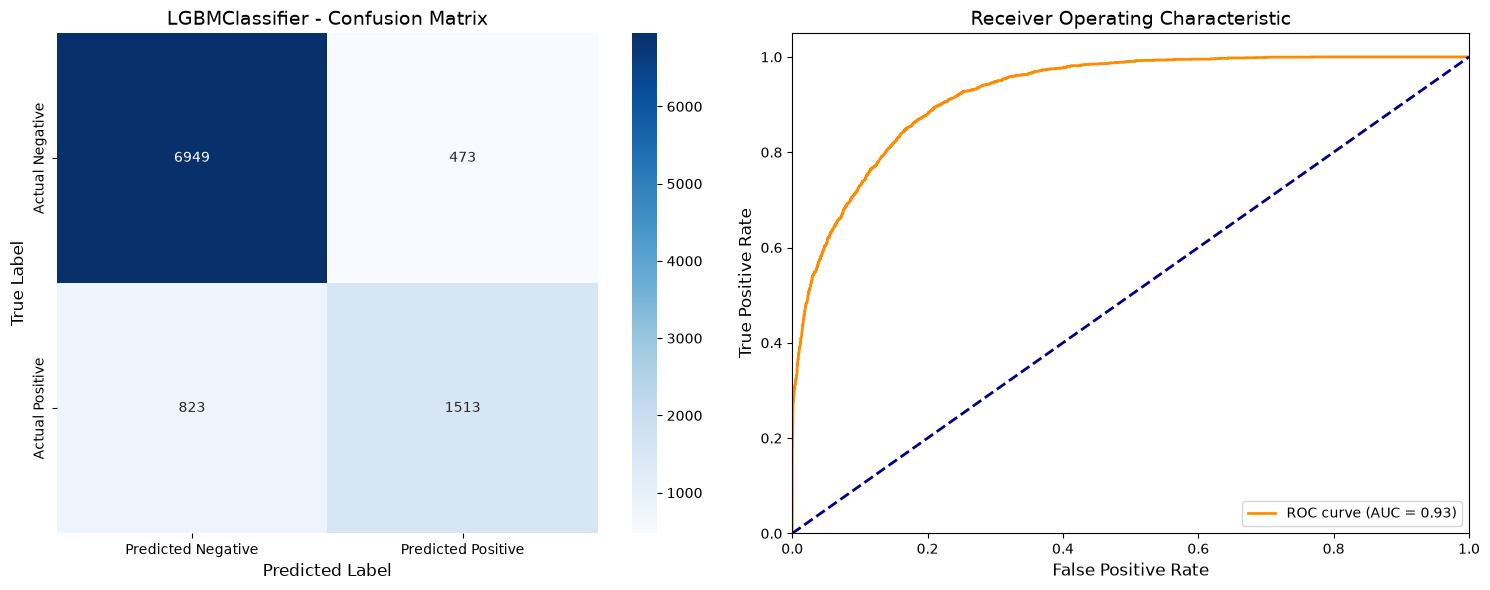


                 LGBMCLASSIFIER EVALUATION                  

MAIN METRICS:
   Metric  Value
  ROC AUC 0.9253
 F1 Score 0.8074
Precision 0.8280
   Recall 0.7920
 Accuracy 0.8672


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.761833 0.647688
Negative   0.894107 0.936271



In [363]:
# Train your model
lgbm = LGBMClassifier(random_state=SEED)
lgbm.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = lgbm.predict(X_test_preprocessed)
y_probs = lgbm.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

# Evaluate
lgbm_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="LGBMClassifier"
)


/home/bibeda/DSpractice/plots.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


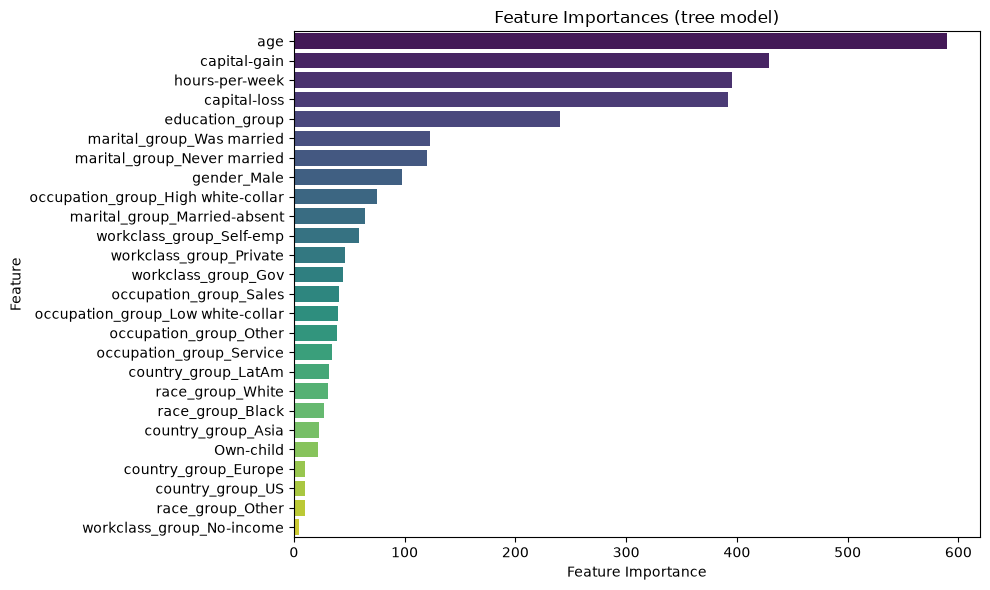

,Feature,Importance
21,age,590
22,capital-gain,429
24,hours-per-week,396
23,capital-loss,392
0,education_group,240
8,marital_group_Was married,123
7,marital_group_Never married,120
1,gender_Male,98
16,occupation_group_High white-collar,75
6,marital_group_Married-absent,64


In [365]:
plot_feature_importance(lgbm, feature_names)

In [366]:
final_metrics = {
    'dummy_classifier': dummy_classifier_metrics,
    'log_reg': log_reg_metrics,
    'decision_tree': decision_tree_metrics,
    'random_forest': random_forest_metrics,
    'lgbm': lgbm_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

<Axes: >

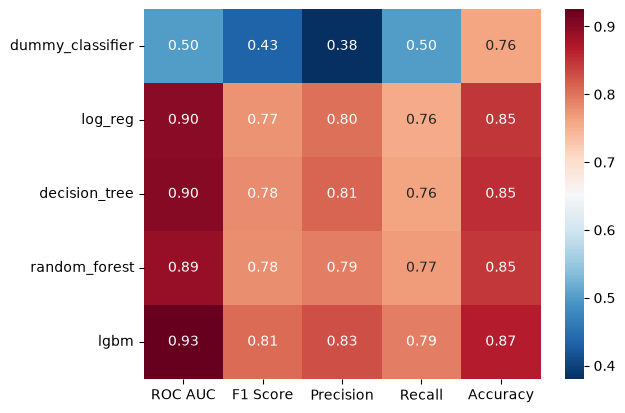

In [367]:
sns.heatmap(result, cmap='RdBu_r', annot=True, fmt=".2f")